In [ ]:
import random
import string

import matplotlib.pyplot as plt
import seaborn as sns

from src.bloom_filter import BloomFilter, BloomFilter_01, BloomFilter_02

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

random.seed(42)

In [17]:
def generate_random_strings(n, length=20):
    """Generate n random alphanumeric strings."""
    chars = string.ascii_letters + string.digits
    return [''.join(random.choices(chars, k=length)) for _ in range(n)]


def measure_false_positive_rate(bf, test_size=10000):
    """Measure false positive rate by testing non-members."""
    test_elements = generate_random_strings(test_size)
    false_positives = sum(1 for elem in test_elements if elem in bf)
    return false_positives / test_size

## Filling up the filter

In [21]:
CAPACITY = 10000
TARGET_FP = 0.01

bf = BloomFilter(capacity=CAPACITY, error_rate=TARGET_FP)


# Measure at different fill levels
fill_levels = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = {'fill_pct': [], 'measured_fp': [], 'estimated_fp': []}

print(f"{'Fill'} | {'Elements'} | {'Measured FP'} | {'Estimated FP'}")


for pct in fill_levels:
    n_elements = int(CAPACITY * pct / 100)
    
    # Add elements to reach this level
    while bf.count < n_elements:
        bf.add(generate_random_strings(1)[0])
    
    # Measure
    fp = measure_false_positive_rate(bf)
    estimated = bf.estimated_error_rate()
    
    results['fill_pct'].append(pct)
    results['measured_fp'].append(fp)
    results['estimated_fp'].append(estimated)
    
    print(f"{pct}% | {n_elements} | {fp} | {estimated:.6f}")

Fill | Elements | Measured FP | Estimated FP
5% | 500 | 0.0 | 0.000000
10% | 1000 | 0.0 | 0.000000
20% | 2000 | 0.0 | 0.000001
30% | 3000 | 0.0 | 0.000011
40% | 4000 | 0.0001 | 0.000067
50% | 5000 | 0.0004 | 0.000251
60% | 6000 | 0.001 | 0.000708
70% | 7000 | 0.0015 | 0.001645
80% | 8000 | 0.0031 | 0.003320
90% | 9000 | 0.0068 | 0.006021
100% | 10000 | 0.0089 | 0.010039


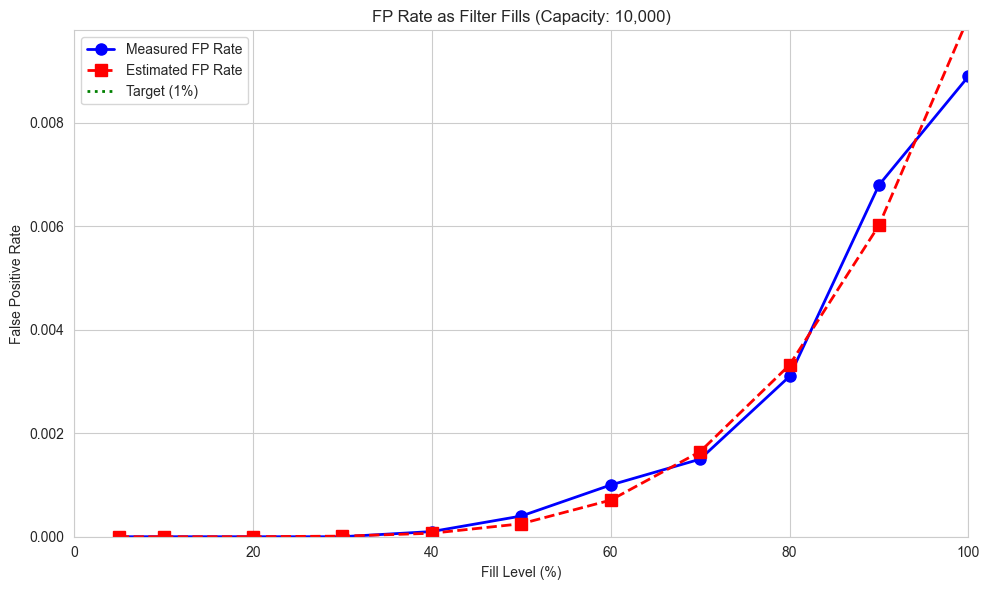

In [22]:
fig, ax = plt.subplots()

ax.plot(results['fill_pct'], results['measured_fp'], 'b-o', 
        label='Measured FP Rate', linewidth=2, markersize=8)
ax.plot(results['fill_pct'], results['estimated_fp'], 'r--s', 
        label='Estimated FP Rate', linewidth=2, markersize=8)
ax.axhline(y=TARGET_FP, color='green', linestyle=':', linewidth=2, 
           label=f'Target ({TARGET_FP:.0%})')

ax.set_xlabel('Fill Level (%)')
ax.set_ylabel('False Positive Rate')
ax.set_title('FP Rate as Filter Fills (Capacity: 10,000)')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, max(results['measured_fp']) * 1.1)

plt.tight_layout()
plt.savefig('./plots/false_positive_vs_fill_level.png', dpi=150, bbox_inches='tight')
plt.show()

## Filter overload

In [23]:
bf_overflow = BloomFilter(capacity=10000, error_rate=0.01)

overflow_levels = [50, 100, 150, 200, 250, 300, 400, 500]

overflow_results = {'overflow_pct': [], 'fp_rate': []}

print(f"{'Overflow'} | {'Elements'} | {'FP Rate'}")
print("-" * 38)

for pct in overflow_levels:
    n_elements = int(CAPACITY * pct / 100)
    
    while bf_overflow.count < n_elements:
        bf_overflow.add(generate_random_strings(1)[0])
    
    fp = measure_false_positive_rate(bf_overflow)
    overflow_results['overflow_pct'].append(pct)
    overflow_results['fp_rate'].append(fp)
    
    print(f"{pct}% | {n_elements} | {fp}")

Overflow | Elements | FP Rate
--------------------------------------
50% | 5000 | 0.0002
100% | 10000 | 0.0084
150% | 15000 | 0.0609
200% | 20000 | 0.159
250% | 25000 | 0.288
300% | 30000 | 0.4303
400% | 40000 | 0.6859
500% | 50000 | 0.8334


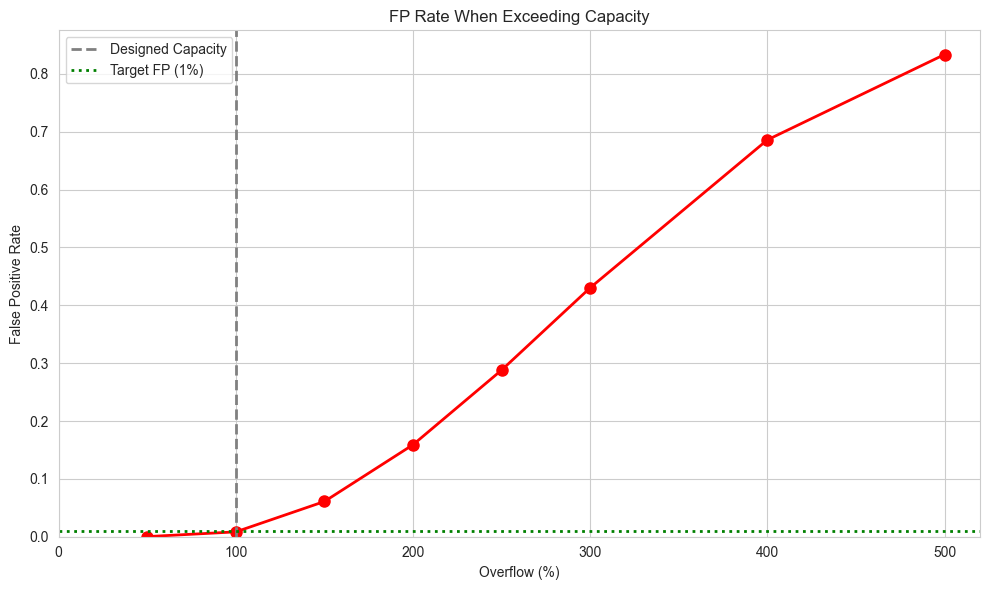

In [24]:
fig, ax = plt.subplots()

ax.plot(overflow_results['overflow_pct'], overflow_results['fp_rate'], 
        'r-o', linewidth=2, markersize=8)
ax.axvline(x=100, color='gray', linestyle='--', linewidth=2, 
           label='Designed Capacity')
ax.axhline(y=TARGET_FP, color='green', linestyle=':', linewidth=2, 
           label=f'Target FP ({TARGET_FP:.0%})')

ax.set_xlabel('Overflow (%)')
ax.set_ylabel('False Positive Rate')
ax.set_title('FP Rate When Exceeding Capacity')
ax.legend()
ax.set_xlim(0, 520)
ax.set_ylim(0, max(overflow_results['fp_rate']) * 1.05)

plt.tight_layout()
plt.savefig('./plots/false_positive_overflow.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare all implementations

In [ ]:
test_points = [1000, 5000, 10000, 20000, 50000]

comparison = {
    'BloomFilter': [],
    'BloomFilter_01': [],
    'BloomFilter_02': []
}

for n in test_points:
    elements = generate_random_strings(n)
    
    # Test each implementation
    bf1 = BloomFilter(capacity=10000, error_rate=0.01)
    bf2 = BloomFilter_01(size=10000, num_hashes=7)
    bf3 = BloomFilter_02(capacity=10000, error_rate=0.01)
    
    for elem in elements:
        bf1.add(elem)
        bf2.add(elem)
        bf3.add(elem)
    
    fp1 = measure_false_positive_rate(bf1)
    fp2 = measure_false_positive_rate(bf2)
    fp3 = measure_false_positive_rate(bf3)
    
    comparison['BloomFilter'].append(fp1)
    comparison['BloomFilter_01'].append(fp2)
    comparison['BloomFilter_02'].append(fp3)


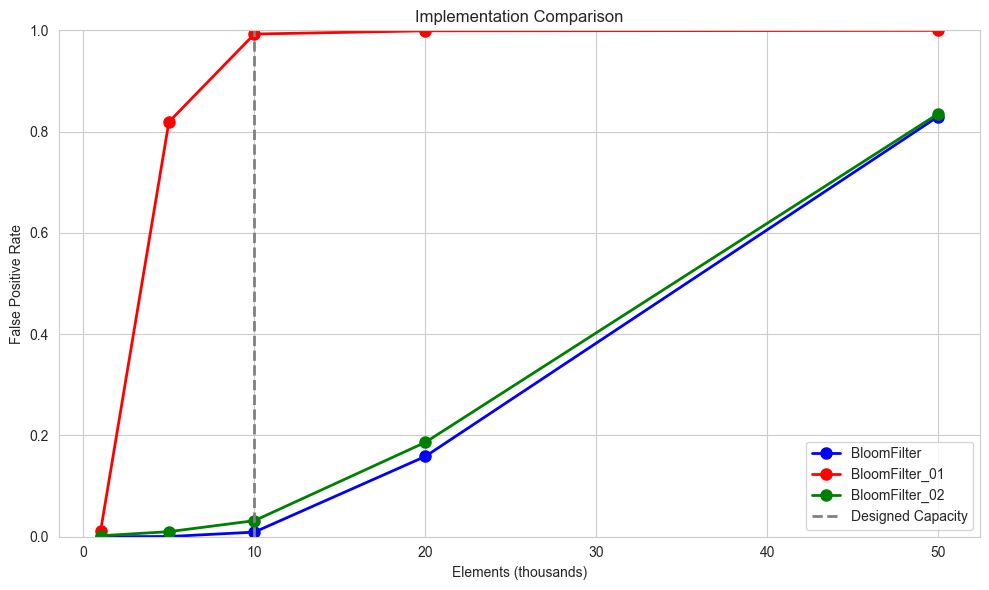

In [27]:
fig, ax = plt.subplots()

colors = ['b', 'r', 'g']
for (name, fp_rates), color in zip(comparison.items(), colors):
    ax.plot([n/1000 for n in test_points], fp_rates, 
            f'{color}-o', label=name, linewidth=2, markersize=8)

ax.axvline(x=10, color='gray', linestyle='--', linewidth=2, 
           label='Designed Capacity')

ax.set_xlabel('Elements (thousands)')
ax.set_ylabel('False Positive Rate')
ax.set_title('Implementation Comparison')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('./plots/false_positive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()